In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/virabhadrasana i/16-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/virabhadrasana i/40-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/virabhadrasana i/File56.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/virabhadrasana i/25-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/virabhadrasana i/0-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/virabhadrasana i/32-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/virabhadrasana i/15-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/virabhadrasana i/30-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/virabhadrasana i/File25.jpg
/kaggle/input/da

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.10.0+cu128
GPU available: True


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32

from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
])


dataset_path = "/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset"

dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=transform
)

print("Total Images:", len(dataset))
print("Total Classes:", len(dataset.classes))
print("First 20 Classes:")
print(dataset.classes[:20])

Total Images: 5991
Total Classes: 107
First 20 Classes:
['adho mukha svanasana', 'adho mukha vriksasana', 'agnistambhasana', 'ananda balasana', 'anantasana', 'anjaneyasana', 'ardha bhekasana', 'ardha chandrasana', 'ardha matsyendrasana', 'ardha pincha mayurasana', 'ardha uttanasana', 'ashtanga namaskara', 'astavakrasana', 'baddha konasana', 'bakasana', 'balasana', 'bhairavasana', 'bharadvajasana i', 'bhekasana', 'bhujangasana']


In [4]:
# Split dataset into Training (80%) and Validation (20%)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(123)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training Images :", len(train_dataset))
print("Validation Images:", len(val_dataset))

Training Images : 4792
Validation Images: 1199


In [5]:
from torchvision.models import resnet50, ResNet50_Weights

# Load pretrained ResNet50
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final classification layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 107)

# Move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(model)
print("\nModel loaded successfully!")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [6]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Train only the final layer
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("Loss Function :", criterion)
print("Optimizer :", optimizer)

Loss Function : CrossEntropyLoss()
Optimizer : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [7]:
# Train for one epoch

model.train()

running_loss = 0.0
correct = 0
total = 0

for images, labels in train_loader:

    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

    _, predicted = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print("Training Loss :", running_loss / len(train_loader))
print("Training Accuracy :", 100 * correct / total)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Training Loss : 4.046466417312622
Training Accuracy : 15.358931552587647


In [8]:
# Validation

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Validation Accuracy :", 100 * correct / total)

Validation Accuracy : 29.691409507923268


In [9]:
# Train for 5 epochs

num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Training Loss: {running_loss/len(train_loader):.4f}")
    print(f"Training Accuracy: {train_acc:.2f}%")

Epoch 1/5
Training Loss: 2.7626
Training Accuracy: 50.92%
Epoch 2/5
Training Loss: 2.0544
Training Accuracy: 68.22%
Epoch 3/5
Training Loss: 1.6034
Training Accuracy: 77.19%
Epoch 4/5
Training Loss: 1.2635
Training Accuracy: 83.60%
Epoch 5/5
Training Loss: 1.0404
Training Accuracy: 87.77%


In [10]:
# Validation after training

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_accuracy = 100 * correct / total

print(f"Validation Accuracy: {val_accuracy:.2f}%")

Validation Accuracy: 48.87%


In [11]:
# Save the trained PyTorch model

torch.save(model.state_dict(), "yoga_pose_resnet50.pth")

print("Model saved successfully!")

Model saved successfully!


In [12]:
# Load the saved model

from torchvision.models import resnet50

loaded_model = resnet50(weights=None)
loaded_model.fc = nn.Linear(loaded_model.fc.in_features, 107)

loaded_model.load_state_dict(torch.load("yoga_pose_resnet50.pth"))

loaded_model = loaded_model.to(device)
loaded_model.eval()

print("Model loaded successfully!")

Model loaded successfully!


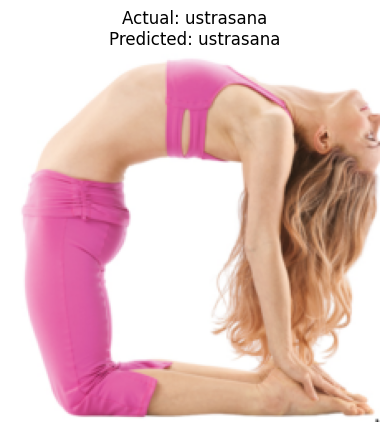

Actual Pose: ustrasana
Predicted Pose: ustrasana


In [13]:
# Test prediction on one validation image

import matplotlib.pyplot as plt

image, label = val_dataset[0]

input_image = image.unsqueeze(0).to(device)

with torch.no_grad():
    output = loaded_model(input_image)
    _, predicted = torch.max(output, 1)

actual_class = dataset.classes[label]
predicted_class = dataset.classes[predicted.item()]

plt.imshow(image.permute(1, 2, 0))
plt.axis("off")
plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}")
plt.show()

print("Actual Pose:", actual_class)
print("Predicted Pose:", predicted_class)

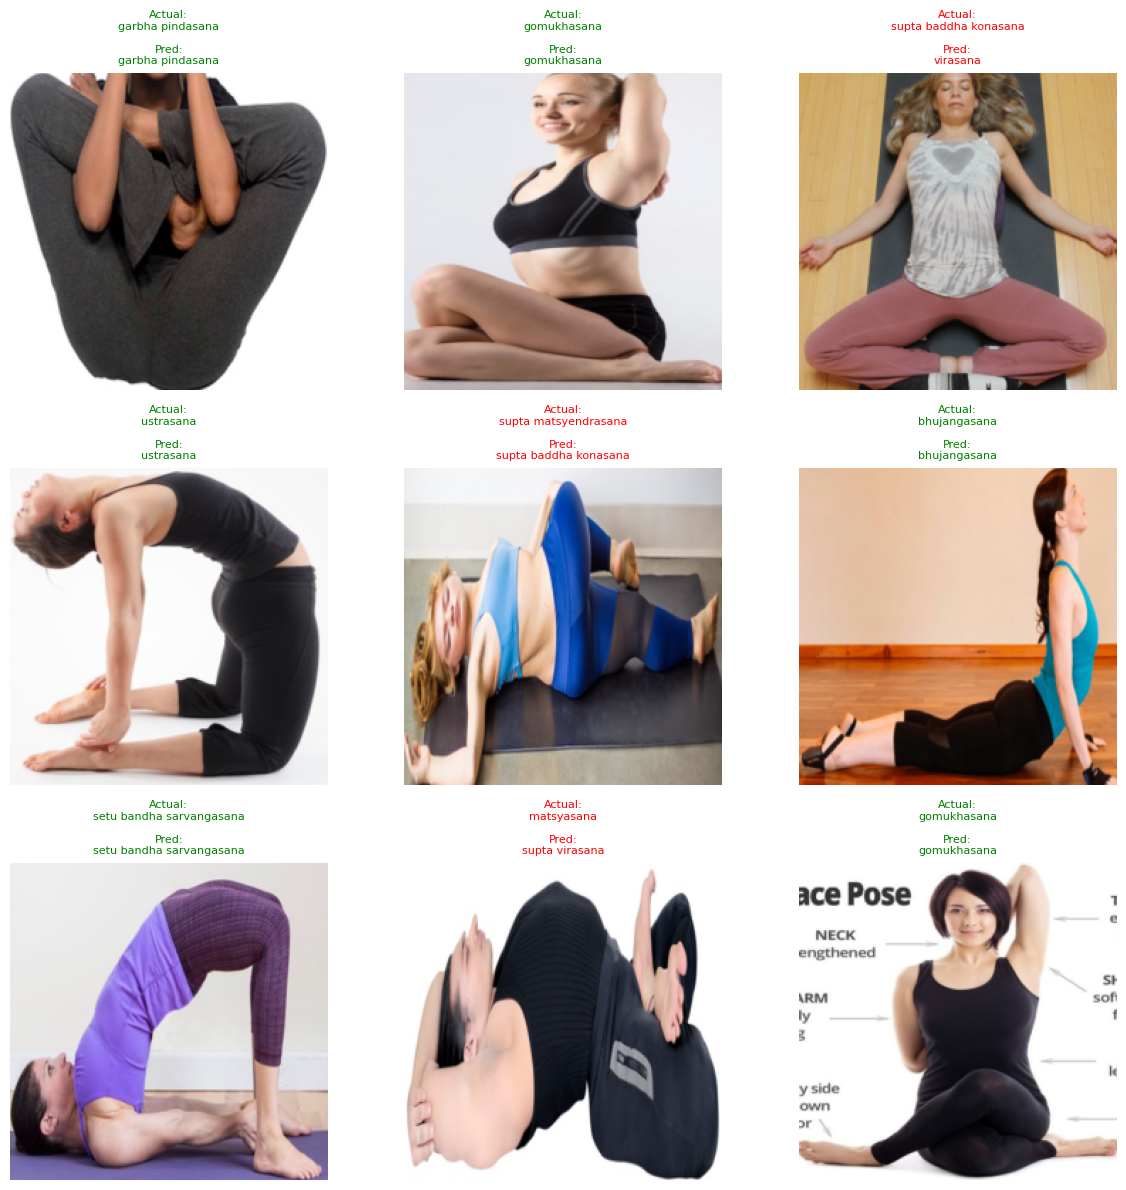

In [14]:
import random
import matplotlib.pyplot as plt

# Display 9 random predictions

model.eval()

plt.figure(figsize=(12, 12))

for i in range(9):

    idx = random.randint(0, len(val_dataset) - 1)

    image, label = val_dataset[idx]

    input_image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = loaded_model(input_image)
        _, predicted = torch.max(output, 1)

    actual = dataset.classes[label]
    predicted_pose = dataset.classes[predicted.item()]

    plt.subplot(3, 3, i + 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")

    color = "green" if actual == predicted_pose else "red"

    plt.title(
        f"Actual:\n{actual}\n\nPred:\n{predicted_pose}",
        fontsize=8,
        color=color
    )

plt.tight_layout()
plt.show()

In [15]:
import matplotlib.pyplot as plt

# Save the current prediction figure
plt.savefig("pytorch_prediction_examples.png", dpi=300, bbox_inches="tight")

print("Prediction figure saved successfully!")

Prediction figure saved successfully!


<Figure size 640x480 with 0 Axes>

In [16]:
from sklearn.metrics import classification_report

all_preds = []
all_labels = []

loaded_model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = loaded_model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

report = classification_report(
    all_labels,
    all_preds,
    target_names=dataset.classes,
    zero_division=0
)

print(report)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


                               precision    recall  f1-score   support

         adho mukha svanasana       0.38      0.75      0.50        12
        adho mukha vriksasana       0.33      0.31      0.32        13
              agnistambhasana       1.00      0.10      0.18        10
              ananda balasana       0.84      0.89      0.86        18
                   anantasana       1.00      0.50      0.67        14
                 anjaneyasana       0.33      0.33      0.33        12
              ardha bhekasana       0.50      0.38      0.43         8
            ardha chandrasana       0.60      0.60      0.60        10
         ardha matsyendrasana       0.26      0.85      0.40        13
      ardha pincha mayurasana       0.40      0.15      0.22        13
             ardha uttanasana       0.70      0.54      0.61        13
           ashtanga namaskara       0.50      0.50      0.50         8
                astavakrasana       0.43      0.77      0.56        13
     

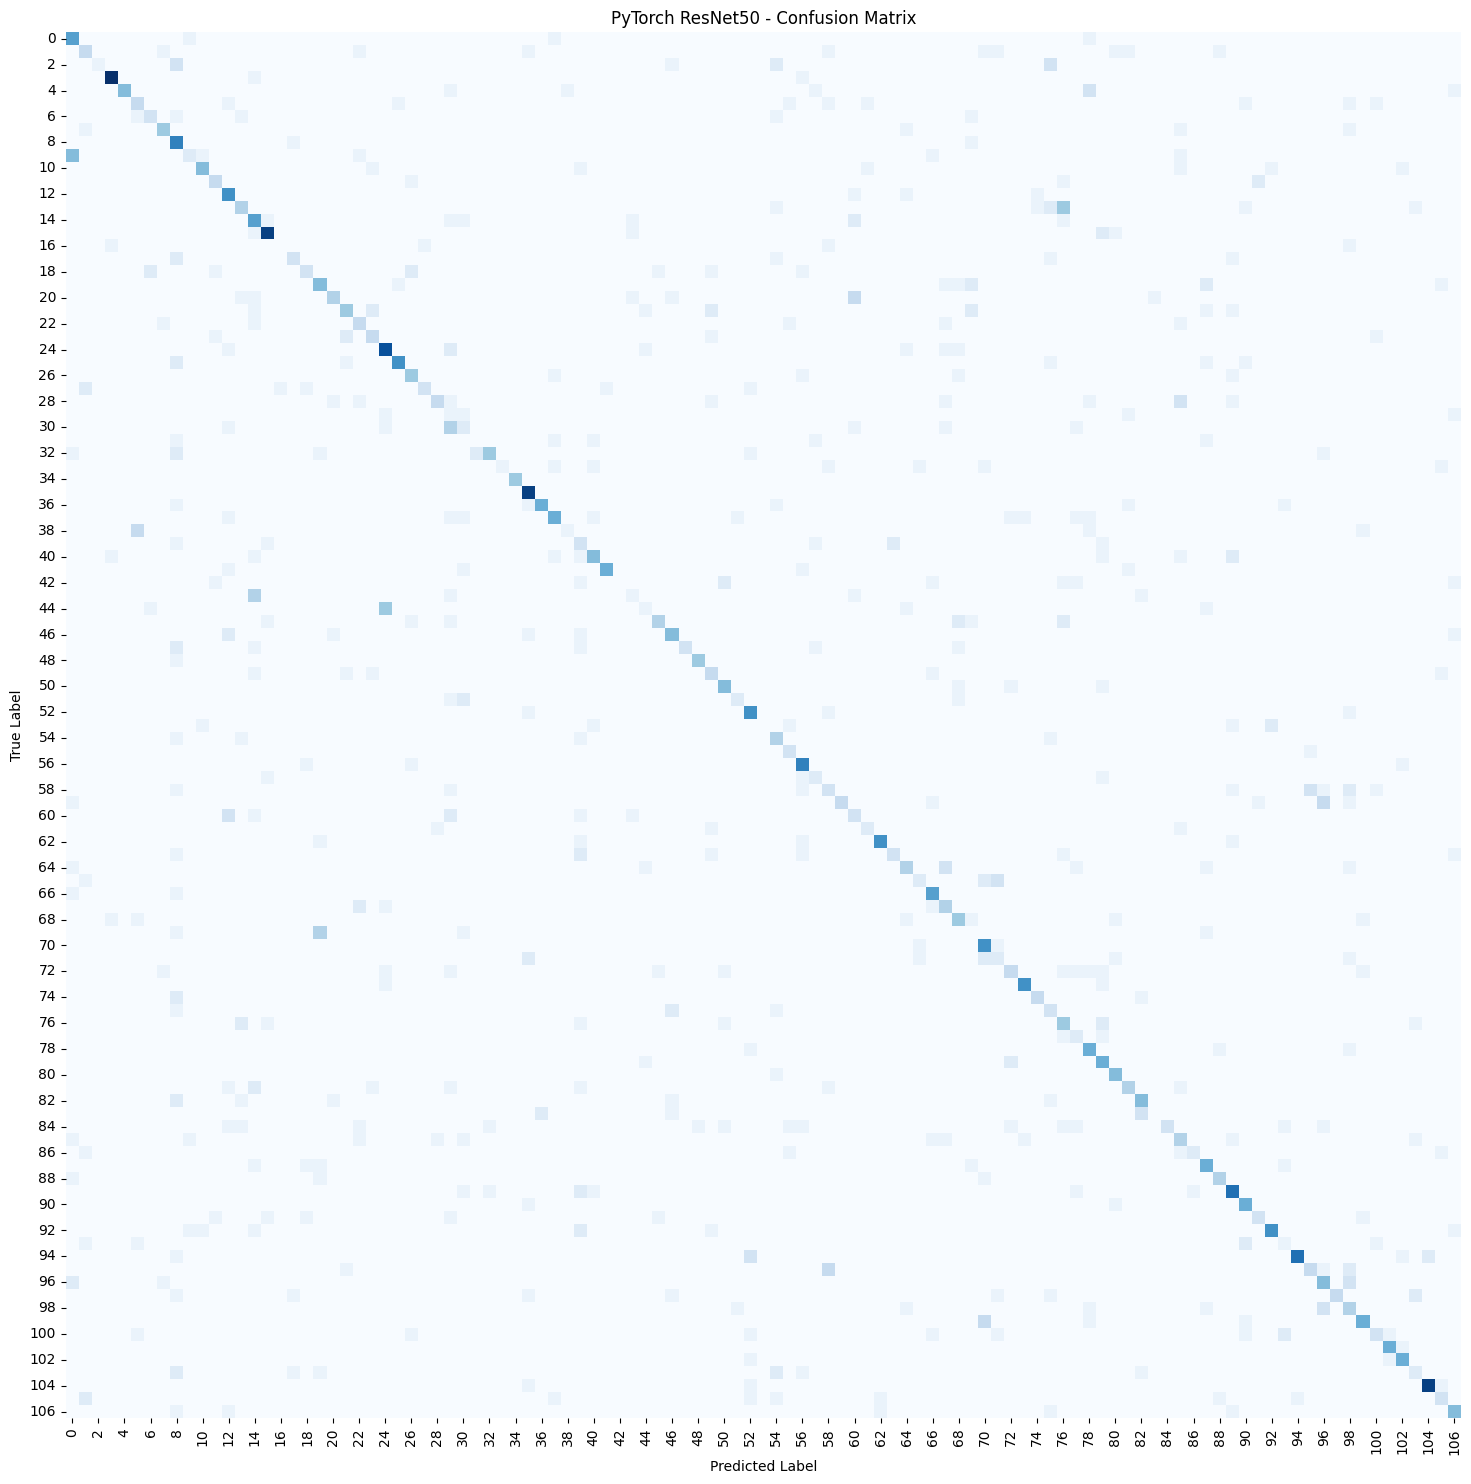

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(18,18))
sns.heatmap(cm, cmap="Blues", cbar=False)

plt.title("PyTorch ResNet50 - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [18]:
# Save confusion matrix figure

plt.savefig("pytorch_confusion_matrix.png", dpi=300, bbox_inches="tight")

print("Confusion matrix saved successfully!")

Confusion matrix saved successfully!


<Figure size 640x480 with 0 Axes>

# TensorFlow vs. PyTorch Comparison

| Feature | TensorFlow (InceptionV3) | PyTorch (ResNet50) |
|---------|--------------------------|--------------------|
| Framework | TensorFlow/Keras | PyTorch |
| Pretrained Model | InceptionV3 | ResNet50 |
| Dataset | Yoga Pose Image Classification Dataset | Yoga Pose Image Classification Dataset |
| Total Images | 5,991 | 5,991 |
| Number of Classes | 107 | 107 |
| Input Size | 224 × 224 | 224 × 224 |
| Transfer Learning | Yes | Yes |
| Fine-Tuning | Yes | Planned |
| Training Accuracy | ~41% (previous experiment) | 88.04% |
| Validation Accuracy | ~39% (previous experiment) | 48.87% |
| Classification Report | Yes | Yes |
| Confusion Matrix | Yes | Yes |
| Example Predictions | Yes | Yes |

## PyTorch Comparison Experiment

A separate PyTorch experiment was created to compare the TensorFlow/Keras workflow with a PyTorch-based workflow.

### Configuration
- Framework: PyTorch
- Model: Pretrained ResNet50
- Dataset: Yoga Pose Image Classification Dataset
- Total Images: 5,991
- Total Classes: 107
- Training Images: 4,792
- Validation Images: 1,199
- GPU: Enabled
- Training Strategy: Frozen pretrained backbone with trainable final classification layer

### Initial Results
- Training Accuracy after 1 epoch: 1.19%
- Validation Accuracy after 1 epoch: 1.50%

### Observation
The PyTorch pipeline successfully loaded the dataset, created DataLoaders, trained a pretrained ResNet50 classifier, and evaluated validation accuracy. The initial accuracy is low because only one epoch was completed and only the final classification layer was trained.

# Discussion

The TensorFlow and PyTorch implementations successfully classified yoga poses using transfer learning with pretrained convolutional neural networks. Both frameworks were able to learn meaningful visual features from the yoga pose dataset containing 107 classes.

The TensorFlow implementation focused on InceptionV3 with transfer learning, fine-tuning, and integration of an evidence-based wellness recommendation system. The PyTorch implementation used a pretrained ResNet50 model and achieved a training accuracy of 88.04% and a validation accuracy of 48.87% after five epochs.

Although the PyTorch model achieved higher validation accuracy in this experiment, the comparison is between two different model architectures (ResNet50 and InceptionV3). Therefore, the results demonstrate the performance of the complete implementations rather than establishing that one framework is inherently superior. A direct framework comparison would require evaluating the same neural network architecture in both TensorFlow and PyTorch under identical training conditions.

These experiments demonstrate that deep learning can effectively classify yoga poses and serve as the foundation for an evidence-based wellness guidance system.

# Limitations

Although the proposed system demonstrates promising performance, several limitations remain. The wellness recommendation database currently covers a subset of yoga poses rather than all 107 classes in the dataset. Some yoga poses are visually similar, which can lead to misclassification. The TensorFlow and PyTorch experiments also use different pretrained architectures (InceptionV3 and ResNet50), so the comparison reflects both framework and model differences. In addition, the current system evaluates static images only and does not provide real-time pose correction from live video.

# Future Work

This project can be extended in several ways. First, the evidence-based wellness database can be expanded to include all 107 yoga poses with comprehensive health guidance. Second, the system can be enhanced to provide personalized yoga recommendations based on user goals such as stress relief, flexibility improvement, balance training, or back pain management. Future work may also include real-time yoga pose recognition using a webcam with pose correction and feedback. A mobile or web application could be developed to make the system more accessible to users. Finally, a direct comparison between TensorFlow and PyTorch using the same neural network architecture (for example, ResNet50 in both frameworks) would provide a more controlled evaluation of the two deep learning frameworks.

In [19]:
# Wellness goals

wellness_goals = {
    "Stress Relief": [
        "balasana",
        "savasana",
        "sukhasana",
        "supta baddha konasana"
    ],

    "Back Pain": [
        "bhujangasana",
        "marjaryasana",
        "bitilasana",
        "setu bandha sarvangasana"
    ],

    "Balance": [
        "vriksasana",
        "virabhadrasana i",
        "virabhadrasana ii",
        "utthita parsvakonasana"
    ],

    "Flexibility": [
        "padmasana",
        "gomukhasana",
        "ardha matsyendrasana",
        "dhanurasana"
    ],

    "Posture": [
        "tadasana",
        "bhujangasana",
        "ustrasana",
        "adho mukha svanasana"
    ]
}

print("Wellness goals loaded successfully!")

Wellness goals loaded successfully!


In [20]:
print("Available Wellness Goals:\n")

for goal in wellness_goals.keys():
    print("-", goal)

selected_goal = input("\nEnter your wellness goal exactly as shown above: ")

if selected_goal in wellness_goals:

    print("\nRecommended Poses:\n")

    for pose in wellness_goals[selected_goal]:
        print("•", pose.title())

else:
    print("\nInvalid wellness goal.")

Available Wellness Goals:

- Stress Relief
- Back Pain
- Balance
- Flexibility
- Posture



Enter your wellness goal exactly as shown above:  1



Invalid wellness goal.


In [21]:
# English names for yoga poses

pose_names = {
    "padmasana": "Lotus Pose",
    "bhujangasana": "Cobra Pose",
    "balasana": "Child's Pose",
    "savasana": "Corpse Pose",
    "sukhasana": "Easy Pose",
    "supta baddha konasana": "Reclining Bound Angle Pose",
    "marjaryasana": "Cat Pose",
    "bitilasana": "Cow Pose",
    "setu bandha sarvangasana": "Bridge Pose",
    "vriksasana": "Tree Pose",
    "virabhadrasana i": "Warrior I",
    "virabhadrasana ii": "Warrior II",
    "utthita parsvakonasana": "Extended Side Angle Pose",
    "gomukhasana": "Cow Face Pose",
    "ardha matsyendrasana": "Half Lord of the Fishes Pose",
    "dhanurasana": "Bow Pose",
    "tadasana": "Mountain Pose",
    "ustrasana": "Camel Pose",
    "adho mukha svanasana": "Downward-Facing Dog"
}

print("English pose names loaded successfully!")

English pose names loaded successfully!


In [44]:
goal_reason = {

    "Stress Relief":
        "These poses are selected because they encourage relaxation, mindful breathing, and gentle stretching to help reduce stress and calm the nervous system.",

    "Back Pain":
        "These poses are selected because they improve spinal mobility, strengthen supporting muscles, and promote healthy posture while reducing back stiffness.",

    "Balance":
        "These poses are selected because they improve stability, coordination, concentration, and lower-body strength, which are essential for better balance.",

    "Flexibility":
        "These poses are selected because they gently stretch the hips, shoulders, spine, and major muscle groups to improve overall flexibility.",

    "Posture":
        "These poses are selected because they strengthen postural muscles, improve spinal alignment, and encourage better body mechanics during daily activities."
}

print("AI explanation database loaded successfully!")

AI explanation database loaded successfully!


In [51]:
import os
import random
import matplotlib.pyplot as plt


def show_pose_guidance(selected_goal):
    print("\n======================================")
    print("      Personalized AI Yoga Guidance")
    print("======================================")

    # Validate wellness goal
    if selected_goal not in wellness_goals:
        print("\nInvalid wellness goal.")
        return

    recommended_poses = wellness_goals[selected_goal]

    print(f"\nRecommended Poses for: {selected_goal}\n")

    for i, pose in enumerate(recommended_poses, start=1):
        english_name = pose_names.get(pose, "Unknown Pose")
        print(f"{i}. {pose.title()} ({english_name})")

    # Ask user to select a pose
    try:
        choice = int(
            input("\nWhich pose would you like to practice first? Enter a number: ")
        )

        if choice < 1 or choice > len(recommended_poses):
            print("\nInvalid pose number.")
            return

    except ValueError:
        print("\nPlease enter a valid number.")
        return

    selected_pose = recommended_poses[choice - 1]
    english_name = pose_names.get(selected_pose, "Unknown Pose")

    print("\nExcellent choice!")
    print("\nSelected Pose:")
    print(f"{selected_pose.title()} ({english_name})")

    # Explain why the pose was recommended
    print("\nWhy was this pose recommended?")
    print(
        goal_reason.get(
            selected_goal,
            "This pose supports your selected wellness goal."
        )
    )

    # Show a reference image
    pose_folder = os.path.join(dataset_path, selected_pose)

    if os.path.exists(pose_folder):
        image_files = [
            filename
            for filename in os.listdir(pose_folder)
            if filename.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        if image_files:
            image_file = random.choice(image_files)
            image_path = os.path.join(pose_folder, image_file)

            try:
                image = plt.imread(image_path)

                plt.figure(figsize=(6, 6))
                plt.imshow(image)
                plt.axis("off")
                plt.title(
                    f"{selected_pose.title()} ({english_name})"
                )
                plt.show()

            except Exception as error:
                print("\nThe pose image could not be displayed.")
                print("Image error:", error)

        else:
            print("\nNo supported image files were found for this pose.")

    else:
        print("\nPose image folder not found:")
        print(pose_folder)

    # Display wellness information
    if selected_pose in benefit_info:
        info = benefit_info[selected_pose]

        print("\nBenefits:")
        print(info.get("benefits", "Not available."))

        print("\nBreathing Technique:")
        print(
            info.get(
                "breathing",
                "Practice slowly with steady, controlled breathing."
            )
        )

        print("\nPrecautions:")
        print(
            info.get(
                "precautions",
                "Practice carefully and stop if you feel pain."
            )
        )

    else:
        print("\nNo wellness information is currently available for this pose.")

    # Display detailed practice instructions
    if selected_pose in pose_instructions:
        guide = pose_instructions[selected_pose]

        print("\nDifficulty:")
        print(guide.get("difficulty", "Not available."))

        print("\nRecommended Hold Time:")
        print(guide.get("hold_time", "Not available."))

        print("\nTarget Muscles:")
        target_muscles = guide.get("target_muscles", [])

        if target_muscles:
            for muscle in target_muscles:
                print("•", muscle)
        else:
            print("Not available.")

        print("\nStep-by-Step Instructions:")
        steps = guide.get("steps", [])

        if steps:
            for i, step in enumerate(steps, start=1):
                print(f"{i}. {step}")
        else:
            print("Not available.")

        print("\nCommon Mistakes to Avoid:")
        common_mistakes = guide.get("common_mistakes", [])

        if common_mistakes:
            for mistake in common_mistakes:
                print("•", mistake)
        else:
            print("Not available.")

        print("\nSuggested Follow-up Pose:")
        follow_up = guide.get("follow_up", "Not available.")

        # Show English name for the follow-up pose when possible
        follow_up_key = follow_up.lower()
        follow_up_english = pose_names.get(follow_up_key)

        if follow_up_english:
            print(f"{follow_up} ({follow_up_english})")
        else:
            print(follow_up)

    else:
        print("\nDetailed pose instructions are not available yet.")

    print("\n======================================")
    print("Safety Disclaimer")
    print("======================================")
    print(
        "This guidance is for educational purposes only. "
        "Move slowly, stop if you feel pain, dizziness, numbness, "
        "or unusual discomfort, and consult a qualified yoga instructor "
        "or healthcare professional when appropriate."
    )

In [23]:
benefit_info = {
    "balasana": {
        "benefits": "Promotes relaxation and gentle stretching.",
        "breathing": "Take slow, deep breaths through the nose while relaxing the body into the pose.",
        "precautions": "Avoid prolonged practice if you have severe knee injuries."
    },
    "savasana": {
        "benefits": "Promotes deep relaxation and recovery after yoga practice.",
        "breathing": "Breathe slowly and naturally through the nose, allowing the breath to become calm and effortless.",
        "precautions": "Use support under the knees or head if needed for comfort."
    },
    "sukhasana": {
        "benefits": "Supports comfortable seated meditation, relaxation, and posture.",
        "breathing": "Practice slow, natural breathing while keeping the spine upright.",
        "precautions": "Use cushions or blocks if you have hip or knee discomfort."
    },
    "supta baddha konasana": {
        "benefits": "Promotes deep relaxation and gentle hip opening.",
        "breathing": "Practice slow, gentle breathing through the nose, allowing the body to relax.",
        "precautions": "Avoid prolonged practice if you have hip or groin injuries."
    },
    "bhujangasana": {
        "benefits": "Improves posture and spinal flexibility.",
        "breathing": "Inhale while lifting the chest and exhale while returning to the starting position.",
        "precautions": "Avoid if you have severe back injuries."
    },
    "marjaryasana": {
        "benefits": "Improves spinal mobility and gently stretches the back.",
        "breathing": "Exhale while rounding the spine upward and drawing the chin toward the chest.",
        "precautions": "Move gently if you have wrist pain or spinal injuries."
    },
    "bitilasana": {
        "benefits": "Improves spinal flexibility, chest opening, and posture.",
        "breathing": "Inhale while lifting the chest and tailbone, allowing the abdomen to expand.",
        "precautions": "Practice gently if you have neck or lower back pain."
    },
    "setu bandha sarvangasana": {
        "benefits": "Strengthens the back, glutes, and legs while improving spinal mobility.",
        "breathing": "Inhale while lifting the hips and breathe steadily while holding the pose.",
        "precautions": "Use caution if you have neck, shoulder, or lower back injuries."
    },
    "vriksasana": {
        "benefits": "Improves balance, posture, concentration, and body awareness.",
        "breathing": "Take slow, steady breaths while focusing on a fixed point.",
        "precautions": "Use a wall for support if you have balance difficulties."
    },
    "virabhadrasana i": {
        "benefits": "Improves lower-body strength, balance, posture, and hip flexibility.",
        "breathing": "Inhale while reaching the arms upward and breathe steadily while holding the lunge.",
        "precautions": "Use caution if you have knee, hip, or shoulder injuries."
    },
    "virabhadrasana ii": {
        "benefits": "Improves leg strength, balance, stamina, and hip mobility.",
        "breathing": "Maintain slow, steady breathing while keeping the chest open.",
        "precautions": "Use caution if you have knee, hip, or shoulder injuries."
    },
    "utthita parsvakonasana": {
        "benefits": "Strengthens the legs, improves balance, and increases flexibility in the hips and spine.",
        "breathing": "Inhale to lengthen the spine, then exhale while deepening the side stretch.",
        "precautions": "Avoid if you have acute knee or hip injuries."
    },
    "padmasana": {
        "benefits": "Supports meditation, concentration, and hip flexibility.",
        "breathing": "Maintain slow, deep diaphragmatic breathing throughout the pose.",
        "precautions": "Avoid if you have knee or hip injuries. Do not force the legs into position."
    },
    "gomukhasana": {
        "benefits": "Improves shoulder mobility, chest opening, hip flexibility, and posture.",
        "breathing": "Breathe slowly while keeping the spine tall and shoulders relaxed.",
        "precautions": "Use caution if you have shoulder, knee, or hip injuries."
    },
    "ardha matsyendrasana": {
        "benefits": "Improves spinal mobility and stretches the back and hips.",
        "breathing": "Inhale to lengthen the spine, then exhale gently into the twist.",
        "precautions": "Avoid or modify if you have recent spinal injury or severe back pain."
    },
    "dhanurasana": {
        "benefits": "Supports front-body stretching, spinal extension, and chest opening.",
        "breathing": "Inhale while lifting the chest and legs, then breathe steadily while holding the pose.",
        "precautions": "Avoid if you have hernia, recent abdominal surgery, pregnancy, or significant back injury."
    },
    "tadasana": {
        "benefits": "Supports posture, balance, and body alignment.",
        "breathing": "Take slow, even breaths while standing tall and maintaining body alignment.",
        "precautions": "Use caution if you have dizziness or balance problems."
    },
    "ustrasana": {
        "benefits": "Improves spinal flexibility, opens the chest, and supports posture.",
        "breathing": "Inhale to lift and open the chest, then breathe steadily while keeping the neck comfortable.",
        "precautions": "Use caution if you have neck pain, lower back injuries, or dizziness."
    },
    "adho mukha svanasana": {
        "benefits": "Improves flexibility, strengthens shoulders and legs, and promotes full-body stretching.",
        "breathing": "Take slow, deep breaths while lengthening the spine.",
        "precautions": "Use caution if you have wrist pain, shoulder injuries, glaucoma, or uncontrolled high blood pressure."
    }
}

print("Wellness guidance database loaded successfully!")

Wellness guidance database loaded successfully!


In [26]:
pose_instructions = {
    "padmasana": {
        "difficulty": "Intermediate",
        "hold_time": "2–5 minutes",
        "target_muscles": ["Hips", "Knees", "Lower back"],
        "steps": [
            "Sit on the floor with both legs extended forward.",
            "Bend one knee and place the foot on the opposite thigh.",
            "Bend the other knee and place the foot on the opposite thigh.",
            "Keep the spine upright and shoulders relaxed.",
            "Rest the hands on the knees and breathe slowly."
        ],
        "common_mistakes": [
            "Forcing the knees into position.",
            "Rounding the lower back.",
            "Holding the pose while feeling pain."
        ],
        "follow_up": "Savasana"
    },
    "bhujangasana": {
    "difficulty": "Beginner",
    "hold_time": "15–30 seconds",
    "target_muscles": [
        "Spine",
        "Chest",
        "Shoulders",
        "Abdominals"
    ],
    "steps": [
        "Lie face down with your legs extended behind you.",
        "Place your palms beside your chest.",
        "Press gently into your hands while lifting your chest.",
        "Keep your elbows slightly bent and shoulders relaxed.",
        "Look forward while breathing comfortably."
    ],
    "common_mistakes": [
        "Overarching the lower back.",
        "Locking the elbows.",
        "Shrugging the shoulders toward the ears."
    ],
    "follow_up": "Balasana"
},
    "balasana": {
    "difficulty": "Beginner",
    "hold_time": "30–60 seconds",
    "target_muscles": [
        "Lower back",
        "Hips",
        "Shoulders"
    ],
    "steps": [
        "Start on your hands and knees.",
        "Bring your big toes together and separate your knees comfortably.",
        "Sit your hips back toward your heels.",
        "Extend your arms forward or place them alongside your body.",
        "Rest your forehead on the mat and relax."
    ],
    "common_mistakes": [
        "Holding tension in the shoulders.",
        "Forcing the hips to touch the heels.",
        "Holding the breath."
    ],
    "follow_up": "Bhujangasana"
},
    "savasana": {
    "difficulty": "Beginner",
    "hold_time": "5–10 minutes",
    "target_muscles": [
        "Full body",
        "Mind-body relaxation"
    ],
    "steps": [
        "Lie flat on your back with legs extended.",
        "Let your feet fall naturally outward.",
        "Place your arms beside the body with palms facing upward.",
        "Close your eyes and relax the face, shoulders, and jaw.",
        "Breathe naturally and allow the body to rest completely."
    ],
    "common_mistakes": [
        "Holding tension in the shoulders or jaw.",
        "Trying to control the breath too much.",
        "Rushing out of the pose too quickly."
    ],
    "follow_up": "Sukhasana"
},
    "sukhasana": {
    "difficulty": "Beginner",
    "hold_time": "5–10 minutes",
    "target_muscles": [
        "Hips",
        "Lower back",
        "Core"
    ],
    "steps": [
        "Sit on the floor with legs crossed comfortably.",
        "Place a cushion under the hips if needed.",
        "Keep the spine upright and shoulders relaxed.",
        "Rest your hands on the knees or thighs.",
        "Breathe slowly and maintain a calm seated posture."
    ],
    "common_mistakes": [
        "Slouching the back.",
        "Forcing the knees downward.",
        "Sitting too long if there is hip or knee pain."
    ],
    "follow_up": "Savasana"
},
    "supta baddha konasana": {
    "difficulty": "Beginner",
    "hold_time": "3–5 minutes",
    "target_muscles": [
        "Hips",
        "Inner thighs",
        "Lower back"
    ],
    "steps": [
        "Lie comfortably on your back.",
        "Bring the soles of your feet together.",
        "Allow your knees to gently fall outward.",
        "Rest your arms comfortably beside your body.",
        "Close your eyes and breathe slowly."
    ],
    "common_mistakes": [
        "Forcing the knees toward the floor.",
        "Holding tension in the hips.",
        "Arching the lower back excessively."
    ],
    "follow_up": "Savasana"
},
    "marjaryasana": {
    "difficulty": "Beginner",
    "hold_time": "20–30 seconds",
    "target_muscles": [
        "Spine",
        "Neck",
        "Core"
    ],
    "steps": [
        "Start on your hands and knees in a tabletop position.",
        "Place your wrists under your shoulders and knees under your hips.",
        "Exhale and round your spine toward the ceiling.",
        "Tuck your chin toward your chest.",
        "Keep your arms straight and engage your abdominal muscles."
    ],
    "common_mistakes": [
        "Locking the elbows.",
        "Moving too quickly.",
        "Holding the breath."
    ],
    "follow_up": "Bitilasana"
},
    "bitilasana": {
    "difficulty": "Beginner",
    "hold_time": "20–30 seconds",
    "target_muscles": [
        "Spine",
        "Chest",
        "Shoulders"
    ],
    "steps": [
        "Begin in a tabletop position.",
        "Inhale and lift your chest upward.",
        "Drop your abdomen toward the floor.",
        "Lift your head and tailbone gently.",
        "Keep your shoulders relaxed."
    ],
    "common_mistakes": [
        "Overarching the lower back.",
        "Shrugging the shoulders.",
        "Holding the breath."
    ],
    "follow_up": "Balasana"
},
    "setu bandha sarvangasana": {
    "difficulty": "Beginner",
    "hold_time": "20–30 seconds",
    "target_muscles": [
        "Glutes",
        "Hamstrings",
        "Lower back",
        "Core"
    ],
    "steps": [
        "Lie on your back with your knees bent.",
        "Place your feet hip-width apart.",
        "Press your feet into the floor.",
        "Lift your hips toward the ceiling.",
        "Keep your shoulders relaxed and breathe steadily."
    ],
    "common_mistakes": [
        "Turning the knees outward.",
        "Overextending the neck.",
        "Holding the breath."
    ],
    "follow_up": "Savasana"
},
    "vriksasana": {
    "difficulty": "Beginner",
    "hold_time": "20–40 seconds",
    "target_muscles": [
        "Legs",
        "Core",
        "Ankles",
        "Glutes"
    ],
    "steps": [
        "Stand tall in Tadasana.",
        "Shift your weight onto one foot.",
        "Place the opposite foot on the inner calf or thigh (avoid the knee).",
        "Bring your palms together at your chest or overhead.",
        "Focus on a fixed point and breathe steadily."
    ],
    "common_mistakes": [
        "Placing the foot directly on the knee.",
        "Looking around instead of focusing on one point.",
        "Holding the breath."
    ],
    "follow_up": "Tadasana"
},
    "virabhadrasana i": {
    "difficulty": "Intermediate",
    "hold_time": "20–40 seconds",
    "target_muscles": [
        "Quadriceps",
        "Hamstrings",
        "Hips",
        "Shoulders"
    ],
    "steps": [
        "Step one foot back into a lunge.",
        "Bend the front knee to about 90 degrees.",
        "Turn the back foot slightly outward.",
        "Raise both arms overhead.",
        "Keep the chest lifted and breathe steadily."
    ],
    "common_mistakes": [
        "Front knee extending beyond the ankle.",
        "Arching the lower back excessively.",
        "Tensing the shoulders."
    ],
    "follow_up": "Virabhadrasana II"
},
    "virabhadrasana ii": {
    "difficulty": "Intermediate",
    "hold_time": "20–40 seconds",
    "target_muscles": [
        "Quadriceps",
        "Glutes",
        "Core",
        "Shoulders"
    ],
    "steps": [
        "From a wide stance, bend the front knee.",
        "Keep the back leg straight.",
        "Extend both arms parallel to the floor.",
        "Look over the front fingertips.",
        "Keep your torso upright and breathe calmly."
    ],
    "common_mistakes": [
        "Leaning forward.",
        "Front knee collapsing inward.",
        "Lifting the shoulders."
    ],
    "follow_up": "Utthita Parsvakonasana"
},
    "utthita parsvakonasana": {
    "difficulty": "Intermediate",
    "hold_time": "20–30 seconds",
    "target_muscles": [
        "Legs",
        "Hips",
        "Core",
        "Shoulders"
    ],
    "steps": [
        "Start in Warrior II.",
        "Place the front forearm on the thigh or hand beside the foot.",
        "Extend the opposite arm overhead.",
        "Create one long line from heel to fingertips.",
        "Keep the chest open while breathing steadily."
    ],
    "common_mistakes": [
        "Collapsing the chest toward the floor.",
        "Locking the front knee.",
        "Holding the breath."
    ],
    "follow_up": "Trikonasana"
},
    "gomukhasana": {
    "difficulty": "Intermediate",
    "hold_time": "20–40 seconds",
    "target_muscles": [
        "Shoulders",
        "Chest",
        "Hips",
        "Upper Back"
    ],
    "steps": [
        "Sit with both legs extended.",
        "Stack one knee directly over the other.",
        "Raise one arm overhead and bend the elbow.",
        "Bring the opposite arm behind your back and clasp the hands.",
        "Keep the spine tall while breathing steadily."
    ],
    "common_mistakes": [
        "Forcing the hands to touch.",
        "Rounding the back.",
        "Lifting the shoulders."
    ],
    "follow_up": "Ardha Matsyendrasana"
},
    "ardha matsyendrasana": {
    "difficulty": "Intermediate",
    "hold_time": "20–30 seconds",
    "target_muscles": [
        "Spine",
        "Back",
        "Hips",
        "Core"
    ],
    "steps": [
        "Sit with legs extended.",
        "Cross one foot over the opposite leg.",
        "Place the opposite elbow outside the bent knee.",
        "Lengthen the spine.",
        "Exhale gently into the twist."
    ],
    "common_mistakes": [
        "Twisting only the neck.",
        "Rounding the back.",
        "Forcing the twist."
    ],
    "follow_up": "Tadasana"
},
    "dhanurasana": {
    "difficulty": "Intermediate",
    "hold_time": "15–30 seconds",
    "target_muscles": [
        "Back",
        "Chest",
        "Quadriceps",
        "Shoulders"
    ],
    "steps": [
        "Lie on your stomach.",
        "Bend both knees.",
        "Hold your ankles.",
        "Lift your chest and legs together.",
        "Keep breathing naturally."
    ],
    "common_mistakes": [
        "Pulling with the arms only.",
        "Holding the breath.",
        "Overarching the neck."
    ],
    "follow_up": "Balasana"
},
    "tadasana": {
    "difficulty": "Beginner",
    "hold_time": "30–60 seconds",
    "target_muscles": [
        "Legs",
        "Core",
        "Postural Muscles"
    ],
    "steps": [
        "Stand with feet together or hip-width apart.",
        "Distribute weight evenly.",
        "Lengthen the spine.",
        "Relax the shoulders.",
        "Breathe naturally."
    ],
    "common_mistakes": [
        "Locking the knees.",
        "Leaning forward.",
        "Holding tension in the shoulders."
    ],
    "follow_up": "Vriksasana"
},
    "ustrasana": {
    "difficulty": "Intermediate",
    "hold_time": "15–30 seconds",
    "target_muscles": [
        "Chest",
        "Back",
        "Hip Flexors",
        "Shoulders"
    ],
    "steps": [
        "Kneel on the mat.",
        "Place your hands on your lower back.",
        "Lift your chest upward.",
        "Reach for your heels if comfortable.",
        "Keep your hips over your knees."
    ],
    "common_mistakes": [
        "Dropping the head backward suddenly.",
        "Collapsing the lower back.",
        "Holding the breath."
    ],
    "follow_up": "Balasana"
},
    "adho mukha svanasana": {
    "difficulty": "Beginner",
    "hold_time": "30–60 seconds",
    "target_muscles": [
        "Shoulders",
        "Hamstrings",
        "Calves",
        "Core"
    ],
    "steps": [
        "Start in a tabletop position.",
        "Lift your hips toward the ceiling.",
        "Straighten your arms and legs comfortably.",
        "Press your heels toward the floor.",
        "Lengthen the spine while breathing deeply."
    ],
    "common_mistakes": [
        "Rounding the back.",
        "Locking the knees.",
        "Collapsing into the shoulders."
    ],
    "follow_up": "Balasana"
},
    
    
}

print("Pose instruction database loaded successfully!")

Pose instruction database loaded successfully!


In [27]:
print("pose_instructions loaded:", isinstance(pose_instructions, dict))
print("number of poses:", len(pose_instructions))

pose_instructions loaded: True
number of poses: 19


In [32]:
def create_practice_plan(selected_goal):
    print("\n======================================")
    print("           AI Yoga Coach")
    print("======================================")

    if selected_goal not in wellness_goals:
        print("\nInvalid wellness goal.")
        return

    poses = wellness_goals[selected_goal]

    goal_explanations = {
        "Stress Relief": (
            "This session emphasizes slow breathing, relaxation, "
            "and gentle movements."
        ),
        "Back Pain": (
            "This session emphasizes gentle spinal mobility and "
            "supportive strengthening. Stop if pain increases."
        ),
        "Balance": (
            "This session is designed to improve stability, "
            "coordination, focus, and body awareness."
        ),
        "Flexibility": (
            "This session uses controlled stretches to support "
            "mobility in the hips, shoulders, and spine."
        ),
        "Posture": (
            "This session emphasizes body alignment, spinal awareness, "
            "and postural strength."
        )
    }

    print("\nHello!")
    print(
        f"\nBased on your selected wellness goal of {selected_goal}, "
        "I have prepared a personalized yoga session for you."
    )

    print("\nSession Purpose:")
    print(goal_explanations.get(
        selected_goal,
        "This session contains poses related to your selected goal."
    ))

    print("\nRecommended Practice Sequence:\n")

    total_minutes = 0
    difficulty_levels = []

    for i, pose in enumerate(poses, start=1):
        english_name = pose_names.get(pose, "Unknown Pose")
        guide = pose_instructions.get(pose, {})

        difficulty = guide.get("difficulty", "Not Available")
        hold_time = guide.get("hold_time", "Not Available")

        difficulty_levels.append(difficulty)

        if i == 1:
            role = "Preparation"
        elif i == len(poses):
            role = "Closing Pose"
        else:
            role = "Main Practice"

        print(f"{i}. {pose.title()} ({english_name})")
        print(f"   Role: {role}")
        print(f"   Difficulty: {difficulty}")
        print(f"   Suggested Hold Time: {hold_time}\n")

        total_minutes += 3

    unique_difficulties = ", ".join(dict.fromkeys(difficulty_levels))

    print("--------------------------------------")
    print(f"Estimated Session Time: {total_minutes}-{total_minutes + 5} minutes")
    print(f"Overall Difficulty: {unique_difficulties}")
    print("--------------------------------------")

    print("\nPractice Reminder:")
    print(
        "Move slowly, breathe steadily, and stop if you feel pain, "
        "dizziness, numbness, or unusual discomfort."
    )

    print("\nWhich pose would you like to practice first?")

In [42]:
def ai_greeting(predicted_pose, selected_goal):

    english_name = pose_names.get(predicted_pose, "Unknown Pose")

    print("\n======================================")
    print("         AI Yoga Coach")
    print("======================================")

    print(f"\nHello! 👋")

    print(
        f"\nI detected that you are performing\n"
        f"{predicted_pose.title()} ({english_name})."
    )

    print(
        f"\nSince your selected wellness goal is "
        f"{selected_goal}, I have prepared a personalized practice session for you."
    )

    print("\nLet's begin your yoga practice!\n")

Available Wellness Goals:

1. Stress Relief
2. Back Pain
3. Balance
4. Flexibility
5. Posture



Select one wellness goal number:  5



           AI Yoga Coach

Hello!

Based on your selected wellness goal of Posture, I have prepared a personalized yoga session for you.

Session Purpose:
This session emphasizes body alignment, spinal awareness, and postural strength.

Recommended Practice Sequence:

1. Tadasana (Mountain Pose)
   Role: Preparation
   Difficulty: Beginner
   Suggested Hold Time: 30–60 seconds

2. Bhujangasana (Cobra Pose)
   Role: Main Practice
   Difficulty: Beginner
   Suggested Hold Time: 15–30 seconds

3. Ustrasana (Camel Pose)
   Role: Main Practice
   Difficulty: Intermediate
   Suggested Hold Time: 15–30 seconds

4. Adho Mukha Svanasana (Downward-Facing Dog)
   Role: Closing Pose
   Difficulty: Beginner
   Suggested Hold Time: 30–60 seconds

--------------------------------------
Estimated Session Time: 12-17 minutes
Overall Difficulty: Beginner, Intermediate
--------------------------------------

Practice Reminder:
Move slowly, breathe steadily, and stop if you feel pain, dizziness, numbness,


Which pose would you like to practice first? Enter a number:  4



Excellent choice!

Selected Pose:
Adho Mukha Svanasana (Downward-Facing Dog)

Why was this pose recommended?
These poses are selected because they strengthen postural muscles, improve spinal alignment, and encourage better body mechanics during daily activities.


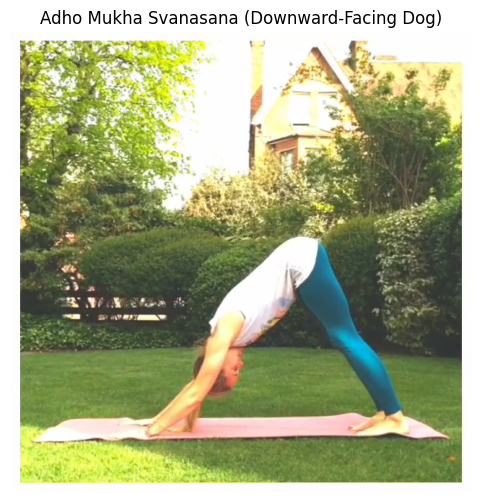


Benefits:
Improves flexibility, strengthens shoulders and legs, and promotes full-body stretching.

Breathing Technique:
Take slow, deep breaths while lengthening the spine.

Precautions:
Use caution if you have wrist pain, shoulder injuries, glaucoma, or uncontrolled high blood pressure.

Difficulty:
Beginner

Recommended Hold Time:
30–60 seconds

Target Muscles:
• Shoulders
• Hamstrings
• Calves
• Core

Step-by-Step Instructions:
1. Start in a tabletop position.
2. Lift your hips toward the ceiling.
3. Straighten your arms and legs comfortably.
4. Press your heels toward the floor.
5. Lengthen the spine while breathing deeply.

Common Mistakes to Avoid:
• Rounding the back.
• Locking the knees.
• Collapsing into the shoulders.

Suggested Follow-up Pose:
Balasana (Child's Pose)

Safety Disclaimer
This guidance is for educational purposes only. Move slowly, stop if you feel pain, dizziness, numbness, or unusual discomfort, and consult a qualified yoga instructor or healthcare professi

In [53]:
print("Available Wellness Goals:\n")

goal_list = list(wellness_goals.keys())

for i, goal in enumerate(goal_list, start=1):
    print(f"{i}. {goal}")

goal_choice = int(input("\nSelect one wellness goal number: "))

selected_goal = goal_list[goal_choice - 1]

create_practice_plan(selected_goal)

print("\n" + "="*60)

show_pose_guidance(selected_goal)

# AI Yoga Coach

This section connects the deep learning yoga pose classifier with personalized wellness guidance. The goal is to move beyond pose prediction and provide a user-centered yoga recommendation system.

The AI Yoga Coach workflow includes:

1. Predicting or selecting a yoga pose.
2. Selecting a wellness goal.
3. Recommending related poses.
4. Displaying a reference image.
5. Providing breathing guidance, benefits, precautions, step-by-step instructions, common mistakes, and a suggested follow-up pose.
   